# Ch.2 — Intraday volume & spread↔vol (MM research memo)

**Plane:** ares-microstructure · paper only  
**Kernel:** Python 3 + `numpy`, `matplotlib`. Run from `research/chapters/ch02_stakes/` (or repo/`research/`).  
**Data:** precomputed `research/out/ch02_stakes/` (warehouse via `uv run` + startarb; no ClickHouse).

---

## Executive takeaway

HL ETH (5 DENSE days): **crypto volume curve ≠ equity U-shape** (\(U\approx 0.56\), peak **18:00 UTC**); **spreads widen with short-horizon vol** (mean corr \(\approx 0.33\)); **tight-spread minutes do not capture majority notional** (\(\pi_{\mathrm{tight}}\approx 0.33\)).

| Decision | Candidates |
|----------|------------|
| **Promote** | `vol.curve_intraday`, `vol.fei_hourly`, `spread.vol_link` |
| **Hold** | `vol.u_shape_ratio`, `share.spread_elasticity`, HFT coverage |
| **Kill** | `spread.tight_notional_share` as share proxy; unlabeled flash proxy |


## Theory & formulas

**Temporal shares (USD notional):** \(q_h = v_h/\sum v_k\), \(\mathrm{FEI}_h = H(q)/\log 24\).

**U-shape ratio:** \(U = \overline{q}_{\{0,1,22,23\}} / \overline{q}_{\{12..15\}}\) (UTC). Equity-like \(\Rightarrow U>1\).

**Spread–vol:** \(s_t = 10^4(A-B)/M\) (bps), \(r_t=|\Delta\log M|\), \(s_t=\alpha+\beta r_t+\varepsilon_t\) @ 1m.

**Honesty:** single-venue HL = **temporal** study. Book §2.2 **spatial** market-share elasticity needs multi-venue trade tape (Hold). Warehouse tape is file-capped — research-grade completeness.


## Data & method

| Item | Value |
|------|-------|
| Venue / symbol | hyperliquid ETH |
| Days | 2026-09-14,15,16,25,26 |
| Trades | `load_trade_tape` (ns clock, `qty_coin`) |
| Quotes | `l2_rebuild`, ~30 quotes/min |
| Buckets | 60s for OLS |
| Outputs | `exp_ch02_eth_summary.json`, `exp_ch02_eth_full.json` |


In [1]:
from __future__ import annotations
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
OUT = next(p for p in [
    HERE/"../../out/ch02_stakes",
    HERE/"out/ch02_stakes",
    HERE/"research/out/ch02_stakes",
] if p.exists()).resolve()
summary = json.loads((OUT/"exp_ch02_eth_summary.json").read_text())
full = json.loads((OUT/"exp_ch02_eth_full.json").read_text())
agg = summary["agg_curve"]
print("OUT", OUT)
print(f"U={agg['mean_u_shape_ratio']:.3f}  FEI_h={agg['mean_fei_hourly']:.3f}  days={summary['days']}")


OUT /home/dev/srv/ares-microstructure/research/out/ch02_stakes
U=0.558  FEI_h=0.892  days=['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-25', '2026-09-26']


## Plot — mean intraday notional curve (UTC)


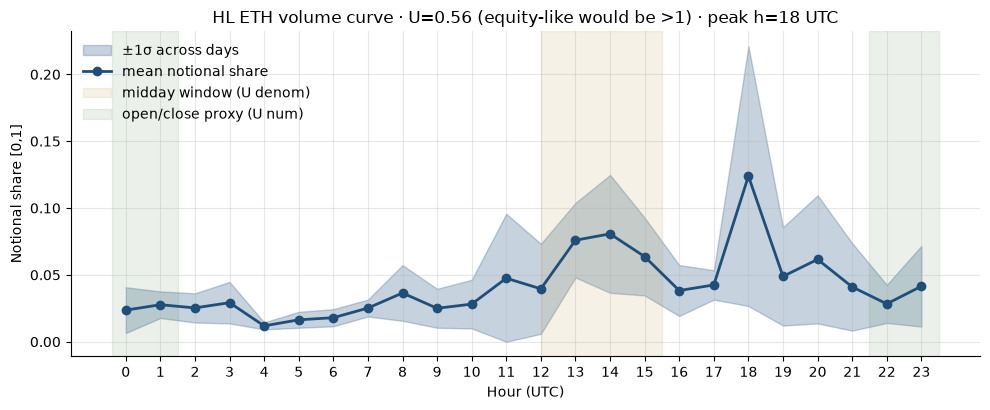

In [2]:
hours = np.arange(24)
mu = np.asarray(agg["mean_hourly_share"])
sd = np.asarray(agg["std_hourly_share"])
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.fill_between(hours, np.maximum(mu-sd,0), mu+sd, alpha=0.25, color="#1f4e79", label="±1σ across days")
ax.plot(hours, mu, "o-", color="#1f4e79", lw=2, label="mean notional share")
ax.axvspan(12, 15.5, color="#c4a35a", alpha=0.15, label="midday window (U denom)")
ax.axvspan(-0.4, 1.5, color="#5b8c5a", alpha=0.12)
ax.axvspan(21.5, 23.5, color="#5b8c5a", alpha=0.12, label="open/close proxy (U num)")
ax.set_xticks(hours); ax.set_xlabel("Hour (UTC)"); ax.set_ylabel("Notional share [0,1]")
ax.set_title(f"HL ETH volume curve · U={agg['mean_u_shape_ratio']:.2f} (equity-like would be >1) · peak h={int(mu.argmax()):02d} UTC")
ax.legend(frameon=False, loc="upper left"); ax.grid(alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()


## Plot — per-day \(U\) and hourly FEI


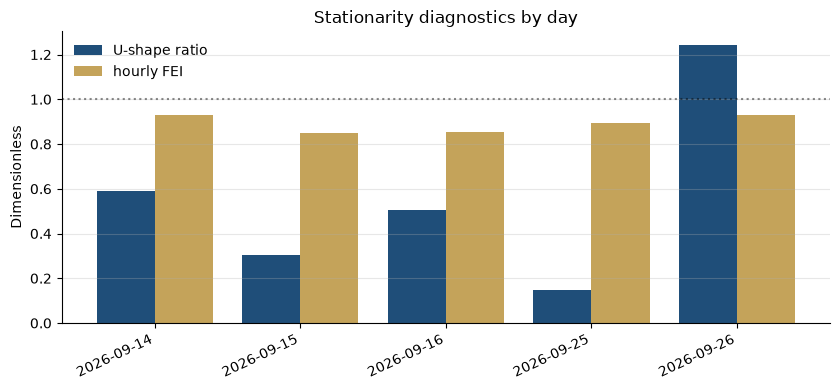

In [3]:
days = [d["day"] for d in summary["per_day"]]
U = [d["volume_curve"]["u_shape_ratio"] for d in summary["per_day"]]
F = [d["volume_curve"]["fei_hourly_share"] for d in summary["per_day"]]
x = np.arange(len(days))
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(x-0.2, U, 0.4, label="U-shape ratio", color="#1f4e79")
ax.bar(x+0.2, F, 0.4, label="hourly FEI", color="#c4a35a")
ax.axhline(1.0, color="k", ls=":", alpha=0.45)
ax.set_xticks(x); ax.set_xticklabels(days, rotation=25, ha="right")
ax.set_ylabel("Dimensionless"); ax.set_title("Stationarity diagnostics by day")
ax.legend(frameon=False); ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()


## Plot — spread vs \(|\Delta\log mid|\) + \(\pi_{\mathrm{tight}}\) check


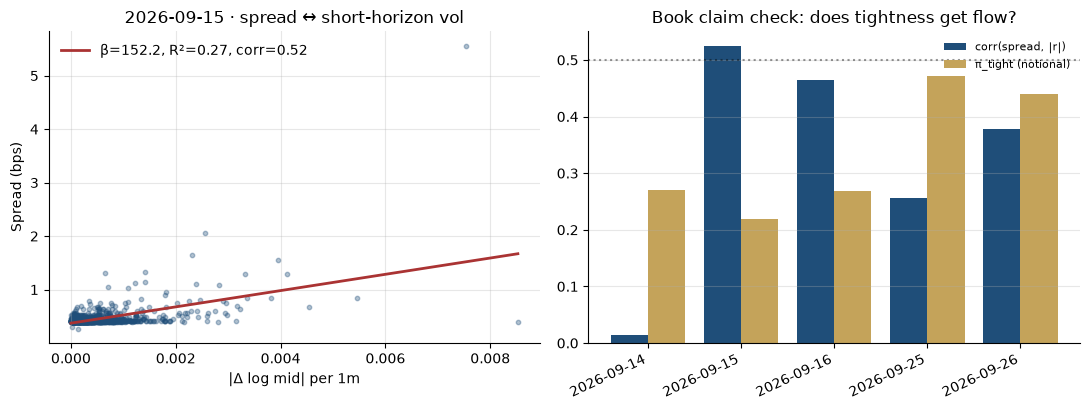

π_tight < 0.5 most days → kill as 'tight wins share' proxy on this venue.


In [4]:
ok = [d for d in full["per_day"] if d["spread_vol_full"].get("ok")]
best = max(ok, key=lambda d: abs(d["spread_vol_full"].get("corr_spread_absret") or 0))
sv = best["spread_vol_full"]
x = np.asarray(sv["abs_logret_series"], float)
y = np.asarray(sv["mean_spread_bps_series"], float)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(x, y, s=10, alpha=0.35, c="#1f4e79")
xx = np.linspace(x.min(), x.max(), 60)
axes[0].plot(xx, sv["ols_alpha_bps"] + sv["ols_beta_bps_per_abs_logret"]*xx, color="#a33", lw=2,
             label=f"β={sv['ols_beta_bps_per_abs_logret']:.1f}, R²={sv['r2']:.2f}, corr={sv['corr_spread_absret']:.2f}")
axes[0].set_xlabel("|Δ log mid| per 1m"); axes[0].set_ylabel("Spread (bps)")
axes[0].set_title(f"{best['day']} · spread ↔ short-horizon vol")
axes[0].legend(frameon=False); axes[0].grid(alpha=0.3)

corrs = [d["spread_vol"]["corr_spread_absret"] for d in summary["per_day"] if d["spread_vol"].get("ok")]
tight = [d["spread_vol"]["notional_tight_share"] for d in summary["per_day"] if d["spread_vol"].get("ok")]
dd = [d["day"] for d in summary["per_day"] if d["spread_vol"].get("ok")]
xx = np.arange(len(dd))
axes[1].bar(xx-0.2, corrs, 0.4, label="corr(spread, |r|)", color="#1f4e79")
axes[1].bar(xx+0.2, tight, 0.4, label="π_tight (notional)", color="#c4a35a")
axes[1].axhline(0.5, color="k", ls=":", alpha=0.4)
axes[1].set_xticks(xx); axes[1].set_xticklabels(dd, rotation=25, ha="right")
axes[1].set_title("Book claim check: does tightness get flow?")
axes[1].legend(frameon=False, fontsize=8); axes[1].grid(axis="y", alpha=0.3)
for ax in axes:
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()
print("π_tight < 0.5 most days → kill as 'tight wins share' proxy on this venue.")


## Interpretation for MM + decisions

| Desk | Read |
|------|------|
| Quoting | Widen with \(\|r\|\); set max size from hour curve (thin 04–06 UTC; heavy 13–20 UTC) |
| Inventory | Budget risk for US-afternoon notional mass |
| SOR | Spatial “tight venue wins share” **untested** — Hold |
| Toxicity | Wide + busy minutes = stress regime |

**Promote:** `vol.curve_intraday`, `vol.fei_hourly`, `spread.vol_link`.  
**Hold:** `vol.u_shape_ratio`, `share.spread_elasticity`.  
**Kill:** `spread.tight_notional_share` as share metric.

Full memo: `EXP_REPORT.md` · cards: `CANDIDATES.md`.
